# Outliers

#### Outliers can arise due to measurement errors, natural variation, or rare events, and they can have a disproportionate impact on statistical analyses and machine learning models if not appropriately handled. 

- Linear regression
- Logistic regression
- adabost
- Deep Learning ( weight based algorithm are affected by outliers)

Tree based are not affected by outliers
but usually we need to remove and handle outliers as we use algorithm in particular datasets.

## How to treats outliers?

- Trimming (completely remove outliers)
- Capping (limit of data and beyound limits are outliers and use only limited values)
- Treat as missing value
- Discretization 

## How to Detect Outliers ?

1. Normal Distribution
   (mean +3 s.d <x< mean-3S.D, if value goes beyound that limit outlier)
2. Skewed Distribution (max>x>min beyond that is outlier)

## Techniques:
- Z score treatment
- IQR based Filtering
- Percentile based
- Winsorization

<p style="font-size:40px; color:red;">Z-Score</p>

Conditions:
- Data need to be normally distributed or bell curve
- (mean +3 s.d <x< mean-3S.D, if value goes beyound that limit outlier)

In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [32]:
df= pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/placement1.csv')
df1= pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/placement1.csv')

In [8]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_95092/2931562495.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_95092/2931562495.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


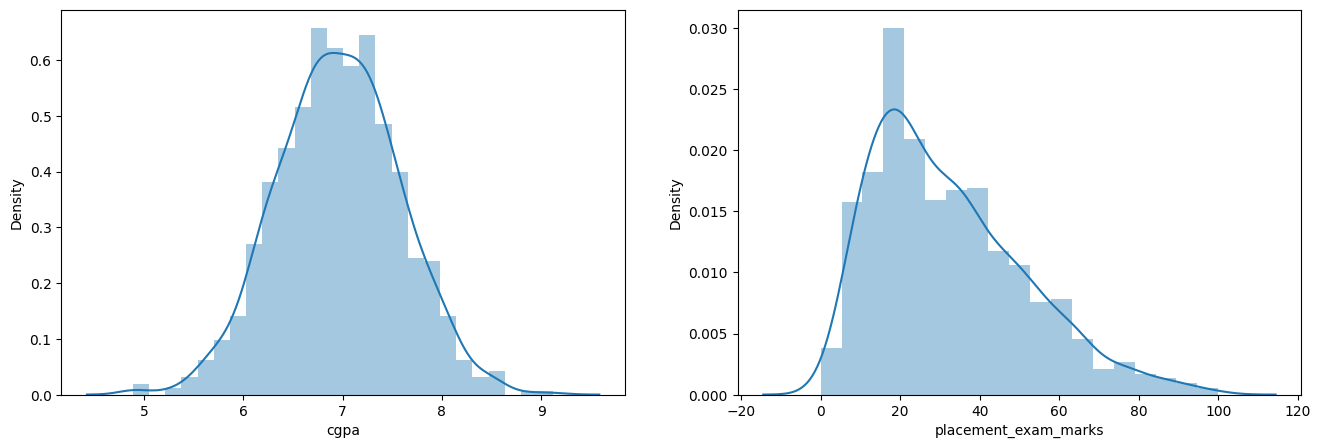

In [12]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])
plt.show()

In [13]:
print("Mean value of cgpa",df['cgpa'].mean())
print("S.D value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
S.D value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [14]:
print("Highest allowed",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed",df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [15]:
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

In [17]:
new_df = df[(df['cgpa']<8.80) & (df['cgpa']>5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


We can also use z-score formula to find the outliers.

# Capping

In [18]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
Lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [30]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<Lower_limit,
        Lower_limit,
        df['cgpa']
    )
)

In [31]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

<p style="font-size:40px; color:red;">IQR</p>

## Terminologies in IQR:
- min(0% means all values in dataset are greater than this.) = (Q1 - 1.5*IQR)
- Q1 (25% means 25 percent of value are less than this .)
- Q2-median (50% means 50 percent value are less or greater than this.)
- Q3 (75% means 75 percent value are less than this.)
- max (100% means 100 percent or all values are less than this.) = (Q1 + 1.5*IQR)

In [33]:
df1.shape

(1000, 3)

In [34]:
df1.sample(5)

,cgpa,placement_exam_marks,placed
555,6.46,32.0,0
855,7.89,9.0,1
117,7.11,0.0,1
326,7.54,13.0,0
806,6.39,15.0,0


In [37]:
df1['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

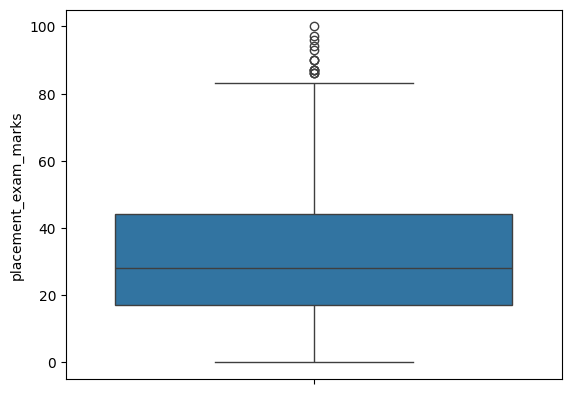

In [38]:
sns.boxplot(df['placement_exam_marks'])

In [39]:
percentiles25 =df1['placement_exam_marks'].quantile(0.25)
percentiles75 =df1['placement_exam_marks'].quantile(0.75)

In [40]:
percentiles25

np.float64(17.0)

In [43]:
iqr = percentiles75-percentiles25

In [44]:
iqr

np.float64(27.0)

In [45]:
upper_limit1 = percentiles75+ 1.5*iqr
lower_limit1 = percentiles25- 1.5*iqr

In [47]:
print(upper_limit1)
print(lower_limit1)

84.5
-23.5


## Trimming

In [48]:
df[df['placement_exam_marks']>upper_limit1]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [50]:
df[df['placement_exam_marks']<lower_limit1]

,cgpa,placement_exam_marks,placed


In [51]:
new_df1 = df[df['placement_exam_marks']<upper_limit1]

In [52]:
new_df1

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_95092/3751205226.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_95092/3751205226.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df1['pla

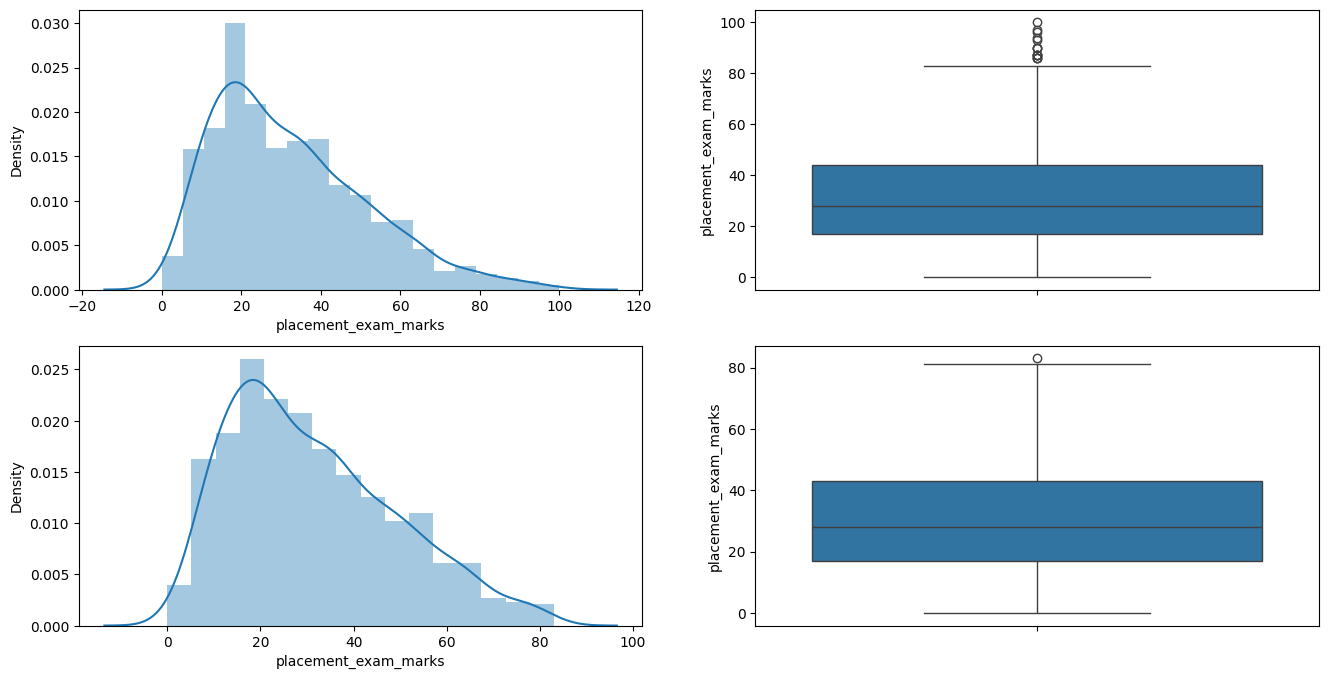

In [53]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df1['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df1['placement_exam_marks'])
plt.show()

## capping

In [56]:
new_cap=df1.copy()
new_cap['placement_exam_marks'] = np.where(
    df1['placement_exam_marks']>upper_limit1,
    upper_limit1,
    np.where(
        df1['placement_exam_marks']<lower_limit1,
        lower_limit1,
        df1['placement_exam_marks']
    )
)

In [57]:
new_cap.shape

(1000, 3)

In [58]:
np.where(condition,true,false)

NameError: name 'condition' is not defined

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_95092/1576306471.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_95092/1576306471.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_cap['pla

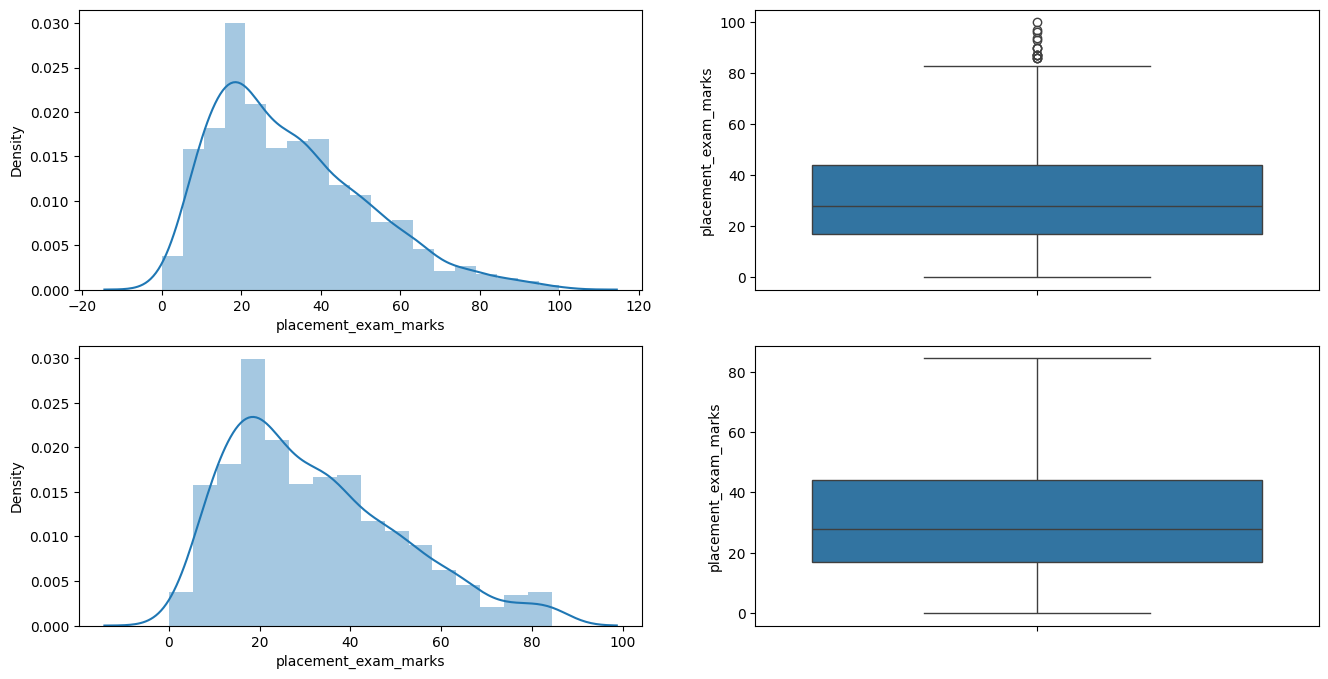

In [60]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_cap['placement_exam_marks'])
plt.show()

<p style="font-size:40px; color:red;">Percentile Method</p>

In [62]:
df2 = pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/weight-height.csv')

In [63]:
df2.head(5)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [67]:
df2.shape

(10000, 3)

In [68]:
df2['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_95092/2667532568.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['Height'])


<Axes: xlabel='Height', ylabel='Density'>

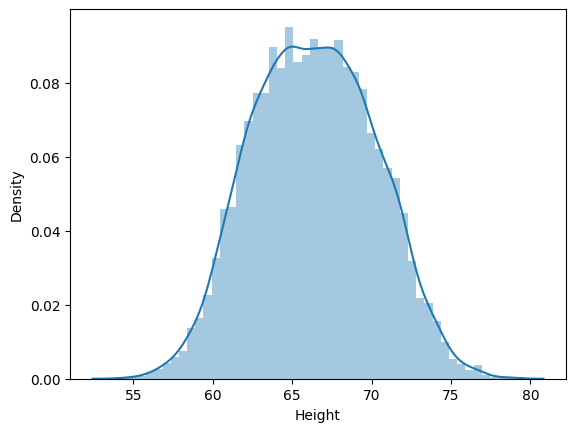

In [69]:
sns.distplot(df2['Height'])
sns.distplot(df2['Height'])

<Axes: ylabel='Height'>

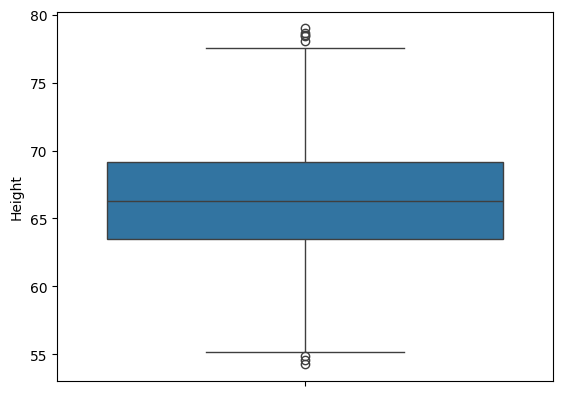

In [70]:
sns.boxplot(df2['Height'])

In [71]:
upper = df2['Height'].quantile(0.99)

In [73]:
upper

np.float64(74.7857900583366)

In [76]:
lower = df2['Height'].quantile(0.01)

In [77]:
lower

np.float64(58.13441158671655)

In [82]:
new= df2[(df2['Height'] <=74.78) & (df2['Height']>=58.13)]


In [83]:
new.describe()

,Height,Weight
count,9799.000000,9799.000000
mean,66.363507,161.391522
std,3.644267,30.925072
min,58.134496,77.523774
25%,63.577147,136.320936
50%,66.317899,161.201891
75%,69.119859,186.747036
max,74.767447,249.946283


/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_95092/3563319298.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new['Height'])


<Axes: xlabel='Height', ylabel='Density'>

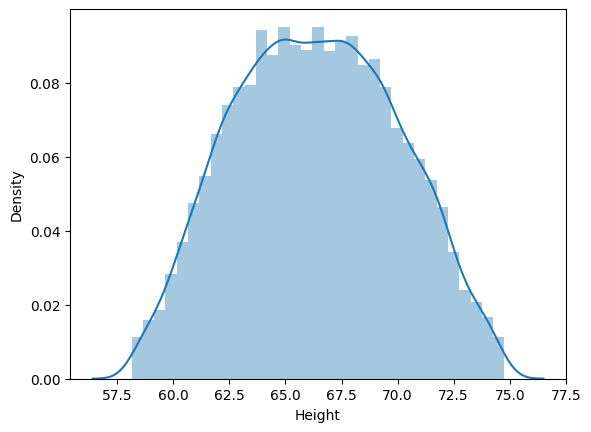

In [87]:
sns.distplot(new['Height'])

<Axes: ylabel='Height'>

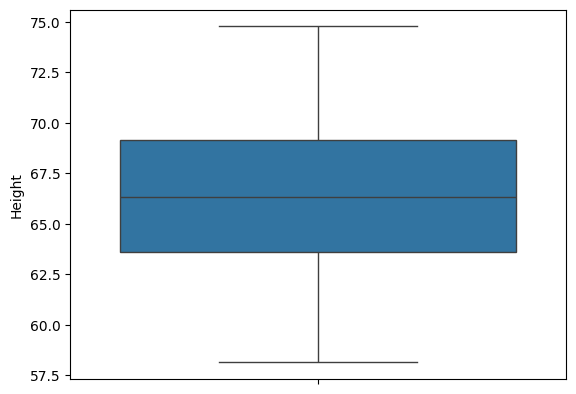

In [85]:
sns.boxplot(new['Height'])

## Capping (Winsorization)

In [91]:
df2['Height']=np.where(df2['Height'] >=upper,
                upper,
                    np.where(df2['Height']<=lower,
                     lower,
                      df2['Height']))
       